In [ ]:
from  google.colab import files
files.upload()

Saving META.csv to META.csv


{'META.csv': b'Date,Open,High,Low,Close,Adj Close,Volume\n2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400\n2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700\n2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600\n2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000\n2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200\n2012-05-25,32.900002,32.950001,31.110001,31.910000,31.910000,37149800\n2012-05-29,31.480000,31.690001,28.650000,28.840000,28.840000,78063400\n2012-05-30,28.700001,29.549999,27.860001,28.190001,28.190001,57267900\n2012-05-31,28.549999,29.670000,26.830000,29.600000,29.600000,111639200\n2012-06-01,28.889999,29.150000,27.389999,27.719999,27.719999,41855500\n2012-06-04,27.200001,27.650000,26.440001,26.900000,26.900000,35230300\n2012-06-05,26.700001,27.760000,25.750000,25.870001,25.870001,42473400\n2012-06-06,26.070000,27.170000,25.520000,26.809999,26.809999,61489200\n2012-06-07,27.0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

#consistent look for every chart
plt.rcParams.update({
    "figure.figsize": (15, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="darkgrid", palette="muted")

OUTPUT = "/mnt/user-data/outputs/"   # change this to "./" if running locally

In [ ]:
df = pd.read_csv("META.csv", parse_dates=["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# helper columns we'll need throughout
df["Year"]       = df["Date"].dt.year
df["Month"]      = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["DayOfWeek"]  = df["Date"].dt.day_name()
df["Quarter"]    = df["Date"].dt.quarter

df["Daily_Return"]     = df["Close"].pct_change()
df["Cumulative_Return"]= (1 + df["Daily_Return"]).cumprod()
df["HL_Spread"]        = df["High"] - df["Low"]   # intraday volatility proxy
df["OC_Spread"]        = df["Close"] - df["Open"] # positive = bullish day

In [ ]:
print("=" * 60)
print("       META STOCK – BASIC DATA OVERVIEW")
print("=" * 60)
print(f"\n  Rows            : {df.shape[0]}")
print(f"  Columns         : {list(df.columns)}")
print(f"  Date Range      : {df['Date'].min().date()}  to  {df['Date'].max().date()}")
print(f"\n  Missing values  :\n{df.isnull().sum().to_string()}")
print(f"\n  Data Types      :\n{df.dtypes.to_string()}")
print("\n  Descriptive Statistics:")
print(df[["Open","High","Low","Close","Volume"]].describe().round(2).to_string())

       META STOCK – BASIC DATA OVERVIEW

  Rows            : 2906
  Columns         : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year', 'Month', 'Month_Name', 'DayOfWeek', 'Quarter', 'Daily_Return', 'Cumulative_Return', 'HL_Spread', 'OC_Spread']
  Date Range      : 2012-05-18  to  2023-12-05

  Missing values  :
Date                 0
Open                 0
High                 0
Low                  0
Close                0
Adj Close            0
Volume               0
Year                 0
Month                0
Month_Name           0
DayOfWeek            0
Quarter              0
Daily_Return         1
Cumulative_Return    1
HL_Spread            0
OC_Spread            0

  Data Types      :
Date                 datetime64[ns]
Open                        float64
High                        float64
Low                         float64
Close                       float64
Adj Close                   float64
Volume                        int64
Year                   

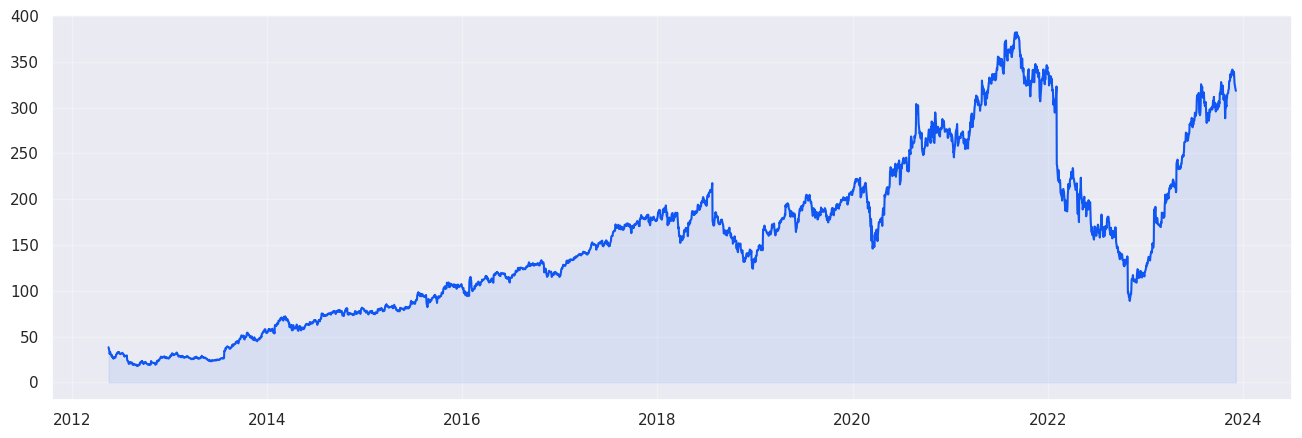

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["Date"], df["Close"], color="#1056F2", linewidth=1.5, label="Close Price")
ax.fill_between(df["Date"], df["Close"], alpha=0.08, color="#1056F2")

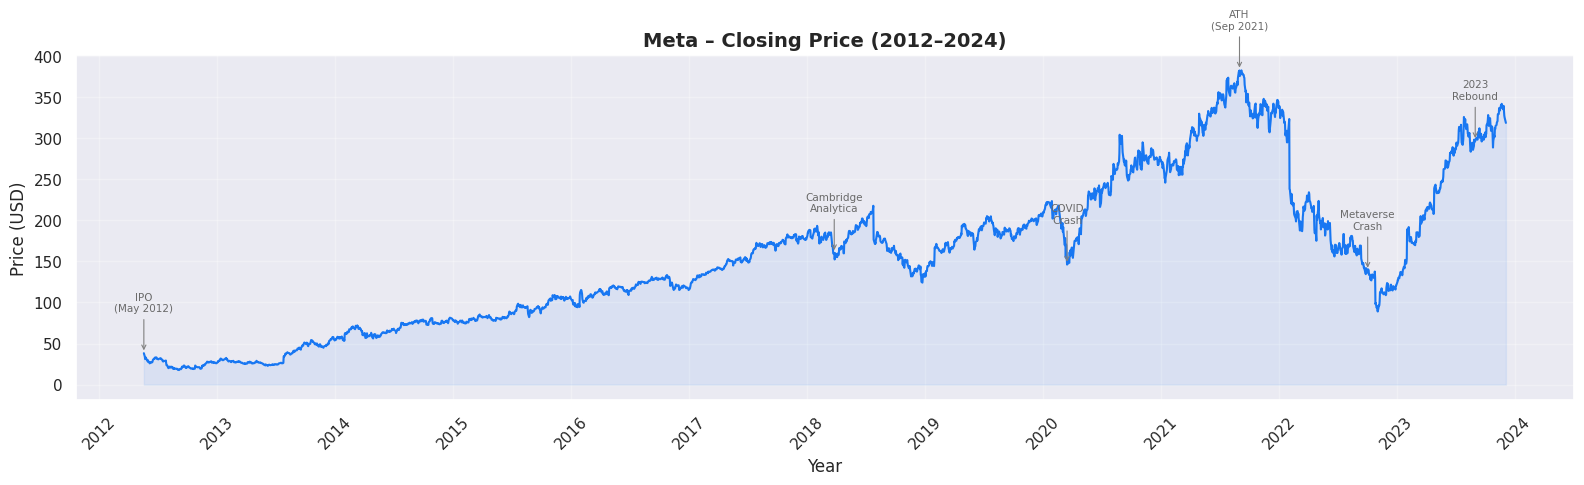

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 5))

# closing price
ax.plot(df["Date"], df["Close"], color="#1877F2", linewidth=1.5, label="Close Price")
ax.fill_between(df["Date"], df["Close"], alpha=0.08, color="#1877F2")

events = {
    "IPO\n(May 2012)"      : "2012-05-18",
    "Cambridge\nAnalytica" : "2018-03-26",
    "COVID\nCrash"         : "2020-03-16",
    "ATH\n(Sep 2021)"      : "2021-09-01",
    "Metaverse\nCrash"     : "2022-10-03",
    "2023\nRebound"        : "2023-09-01",
}

for label, date in events.items():
    row = df[df["Date"] == pd.Timestamp(date)]
    if row.empty:
        row = df[df["Date"] >= pd.Timestamp(date)].head(1)
    if not row.empty:
        px = row["Close"].values[0]
        ax.annotate(label, xy=(row["Date"].values[0], px),
                    xytext=(0, 30), textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
                    fontsize=7.5, ha="center", color="dimgray")

ax.set_title("Meta – Closing Price (2012–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()

OUTPUT = "./outputs/"
os.makedirs(OUTPUT, exist_ok=True)
plt.savefig(OUTPUT + "01_closing_price.png", dpi=150)
plt.show()


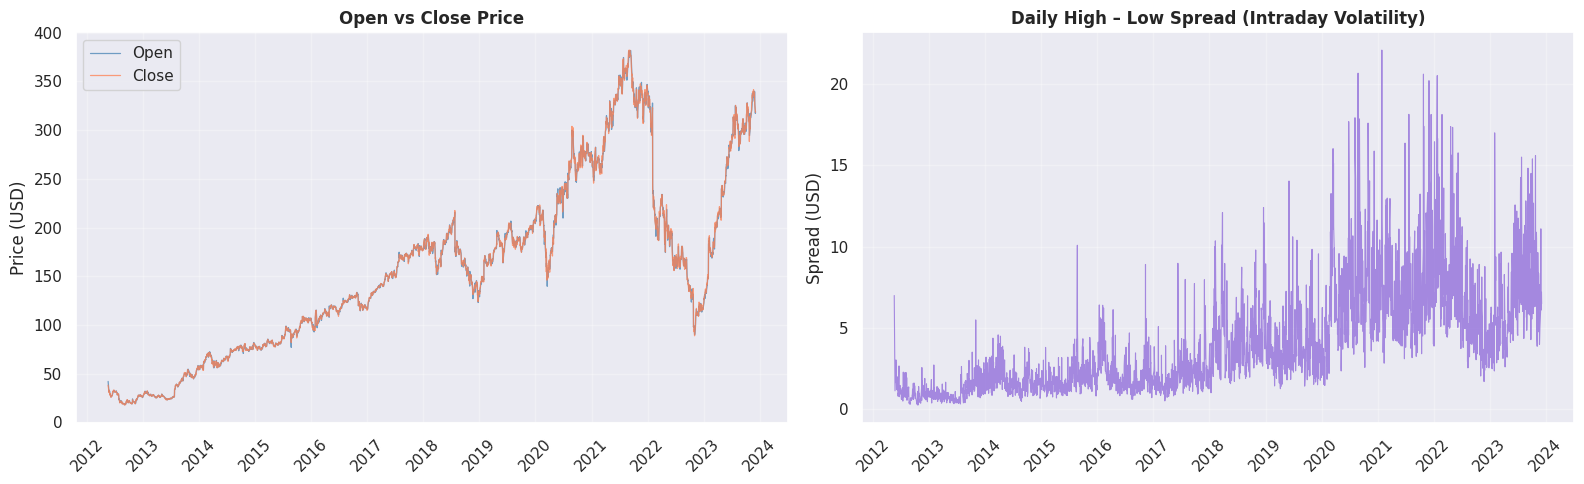

Open/Close & Spread


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df["Date"], df["Open"],  label="Open",  color="steelblue",  alpha=0.75, linewidth=0.9)
axes[0].plot(df["Date"], df["Close"], label="Close", color="coral",      alpha=0.75, linewidth=0.9)
axes[0].set_title("Open vs Close Price", fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

axes[1].plot(df["Date"], df["HL_Spread"], color="mediumpurple", linewidth=0.8, alpha=0.8)
axes[1].set_title("Daily High – Low Spread (Intraday Volatility)", fontweight="bold")
axes[1].set_ylabel("Spread (USD)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT + "02_open_close_spread.png", dpi=150)
plt.show()
print("Open/Close & Spread")

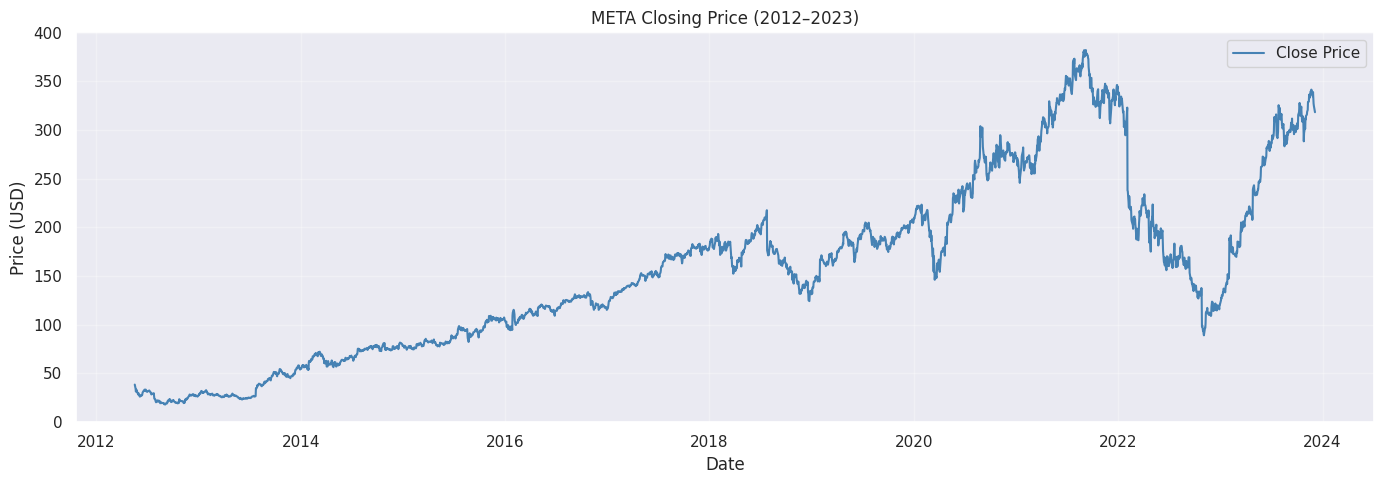

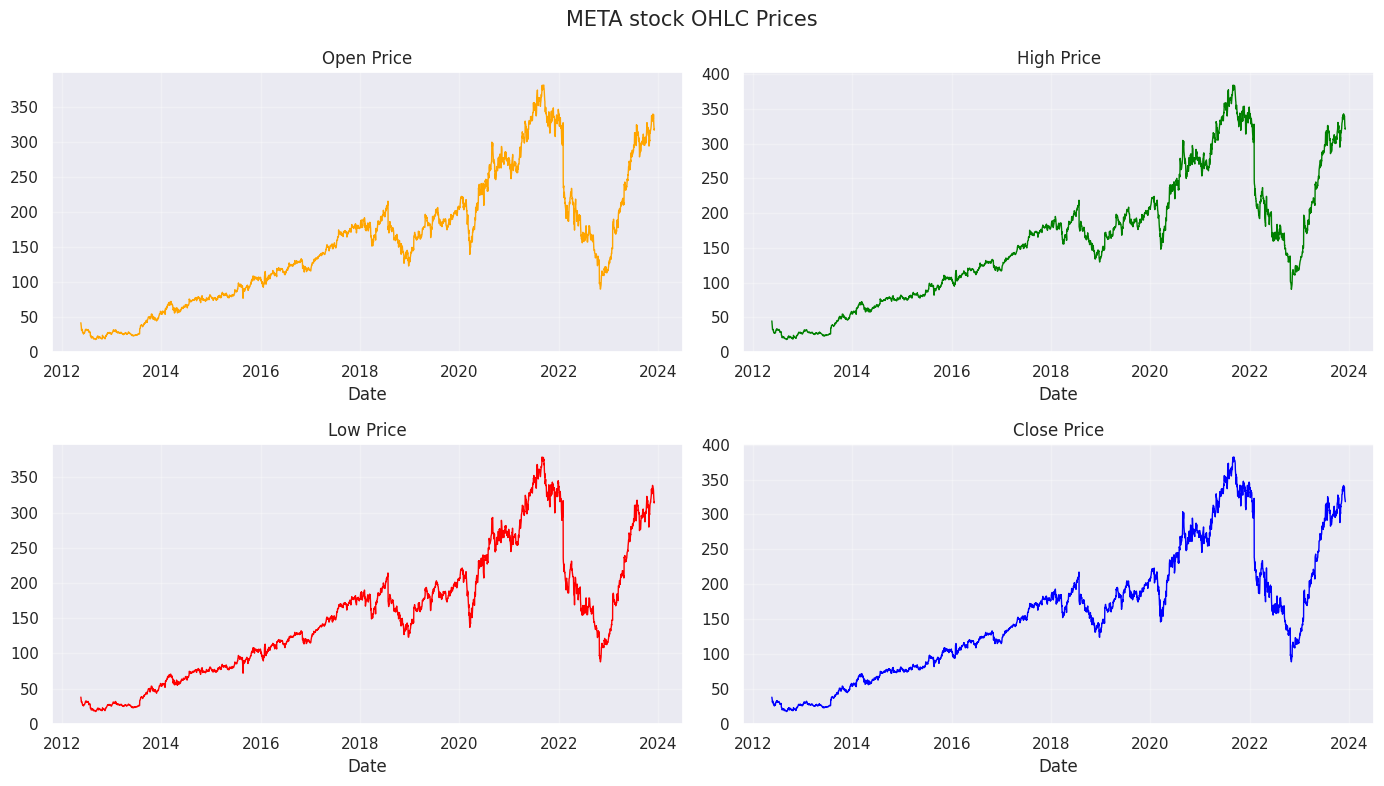

In [9]:
import plotly.graph_objects as go

plt.figure(figsize=(14,5))#drawing canvas
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5, label='Close Price')
plt.title('META Closing Price (2012–2023)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()#makes the label visible to the user
plt.tight_layout()
#we can also prevent overlapping using figure.autofmt_xdate()
plt.show()
fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'], high=df['High'],
    low=df['Low'],  close=df['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])
fig.update_layout(title='META stock Candlestick Chart', xaxis_title='Date',
    yaxis_title='Price', xaxis_rangeslider_visible=True, width=1400,  # Width in pixels
    height=700)
fig.show()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, color in zip(axes.flatten(),
     ['Open','High','Low','Close'],
     ['orange','green','red','blue']):
    ax.plot(df['Date'], df[col], color=color, linewidth=1)
    ax.set_title(f'{col} Price')
    ax.set_xlabel('Date')
plt.suptitle('META stock OHLC Prices', fontsize=15)
plt.tight_layout()
plt.show()

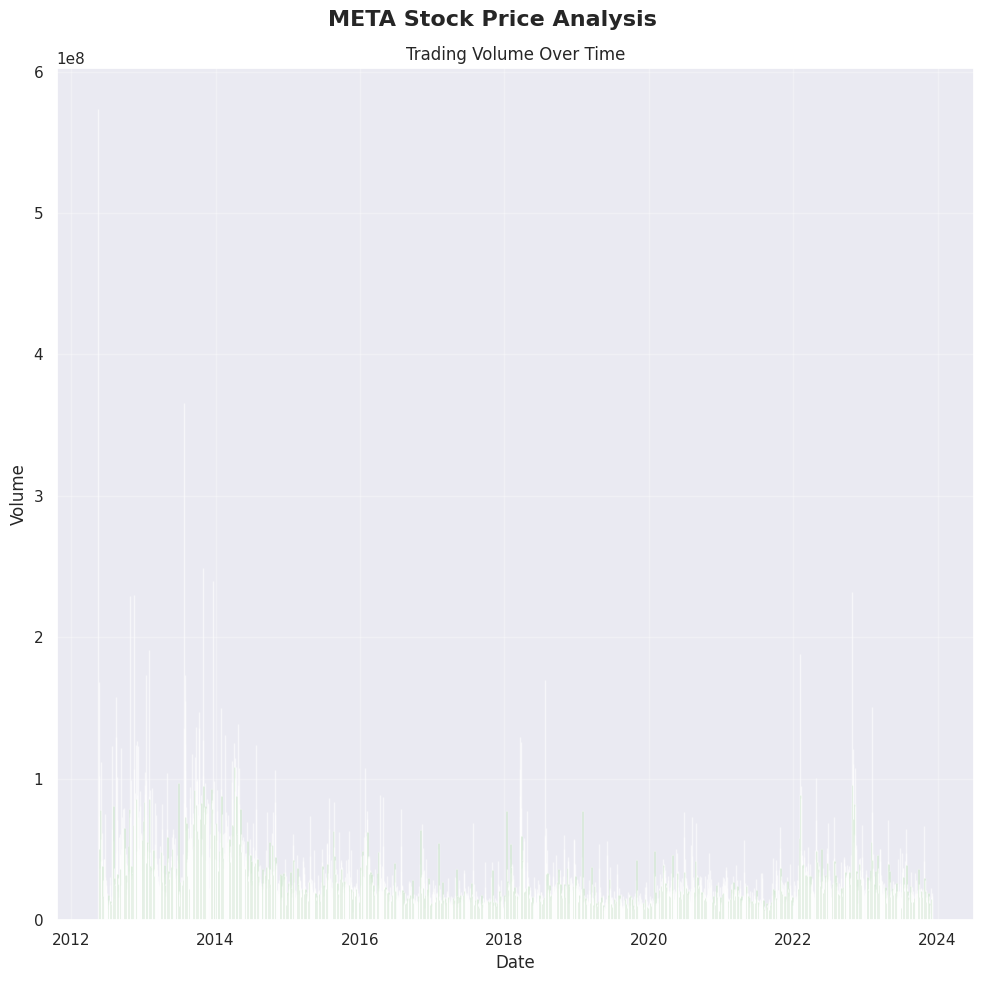

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_price_trends(df, symbol):
    """Create price trend visualizations"""

    fig, axes = plt.subplots(1, 1, figsize=(10, 10))
    fig.suptitle(f'{symbol} Stock Price Analysis', fontsize=16, fontweight='bold')


 # Trading Volume
    axes.bar(df['Date'], df['Volume'], alpha=0.6, color='green')
    axes.set_title('Trading Volume Over Time')
    axes.set_xlabel('Date')
    axes.set_ylabel('Volume')
    axes.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

ticker = 'META' # Define the ticker variable(This tells the name with which the stock is identified)

# Ensure 'data' DataFrame is prepared with all necessary columns
data = df.copy() # Initialize data from df (assuming df is already loaded from previous cells)

data['Date'] = pd.to_datetime(data['Date']) # Convert 'Date' column to datetime objects
data['Month'] = data['Date'].dt.month # Extract month as a new column

# Add required financial indicators for plotting
data["Daily_Return"] = data["Close"].pct_change()
data["MA_10"] = data["Close"].rolling(10).mean()
data["MA_50"] = data["Close"].rolling(50).mean()
data["MA_200"] = data["Close"].rolling(200).mean() # Calculate 200-day Moving Average

plot_price_trends(data, ticker) # Call the function with the preprocessed 'data' DataFrame

b)Trading volume over time

1. The trading volume fluctuates significantly over time, indicating varying levels of investor participation and market activity.

2. Several sharp spikes in trading volume are observed around 2012-13, 2014-16, 2018-20 and 2022-24, suggesting periods of increased buying and selling activity in the market.

3. The highest trading volumes are observed during 2022–2023, indicating strong market participation and heightened investor interest during this period.

a) Bullish Interpretation

If stock price increased along with high volume:

1. buyers were strong

2 .uptrend had strong support

b) Bearish Interpretation

If stock price fell during high volume:

1. sellers dominated

2. panic selling may have occured

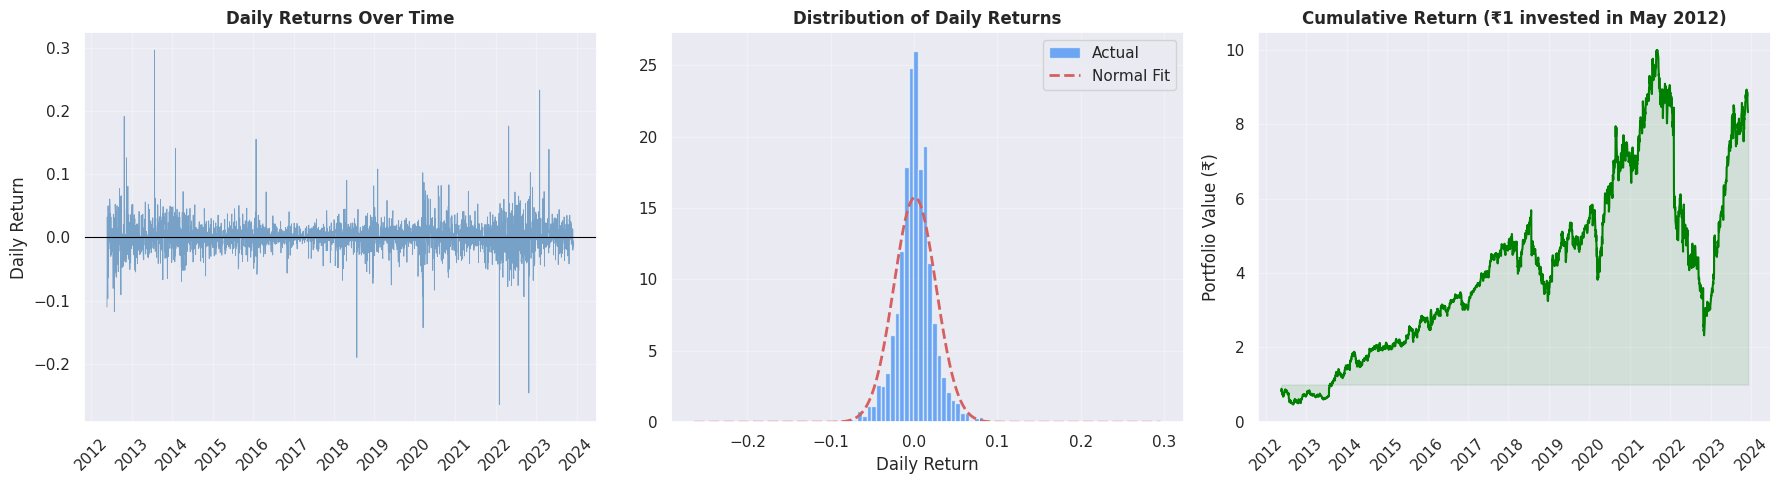


 RETURN STATISTICS:
  Mean Daily Return  : 0.1051%
  Std Dev            : 2.5328%
  Skewness           : 0.2921  (right-skewed – more good days)
  Kurtosis           : 20.8541  (fat tails = yes – extreme moves are common)
Returns & Distribution


In [11]:
returns = df["Daily_Return"].dropna()
mu, sigma = returns.mean(), returns.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# time series of daily returns
axes[0].plot(df["Date"], df["Daily_Return"], color="steelblue", linewidth=0.6, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Daily Returns Over Time", fontweight="bold")
axes[0].set_ylabel("Daily Return")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# histogram with normal curve overlay
axes[1].hist(returns, bins=100, color="#1877F2", alpha=0.6, density=True, label="Actual")
x = np.linspace(returns.min(), returns.max(), 300)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=2, label="Normal Fit")
axes[1].set_title("Distribution of Daily Returns", fontweight="bold")
axes[1].set_xlabel("Daily Return")
axes[1].legend()

# cumulative return
axes[2].plot(df["Date"], df["Cumulative_Return"], color="green", linewidth=1.5)
axes[2].fill_between(df["Date"], df["Cumulative_Return"], 1, alpha=0.1, color="green")
axes[2].set_title("Cumulative Return (₹1 invested in May 2012)", fontweight="bold")
axes[2].set_ylabel("Portfolio Value (₹)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT + "03_returns_distribution.png", dpi=150)
plt.show()

# stats
print("\n RETURN STATISTICS:")
print(f"  Mean Daily Return  : {mu*100:.4f}%")
print(f"  Std Dev            : {sigma*100:.4f}%")
print(f"  Skewness           : {returns.skew():.4f}  ({'left-skewed – more bad days' if returns.skew() < 0 else 'right-skewed – more good days'})")
print(f"  Kurtosis           : {returns.kurtosis():.4f}  (fat tails = {'yes – extreme moves are common' if returns.kurtosis() > 3 else 'no'})")
print("Returns & Distribution")

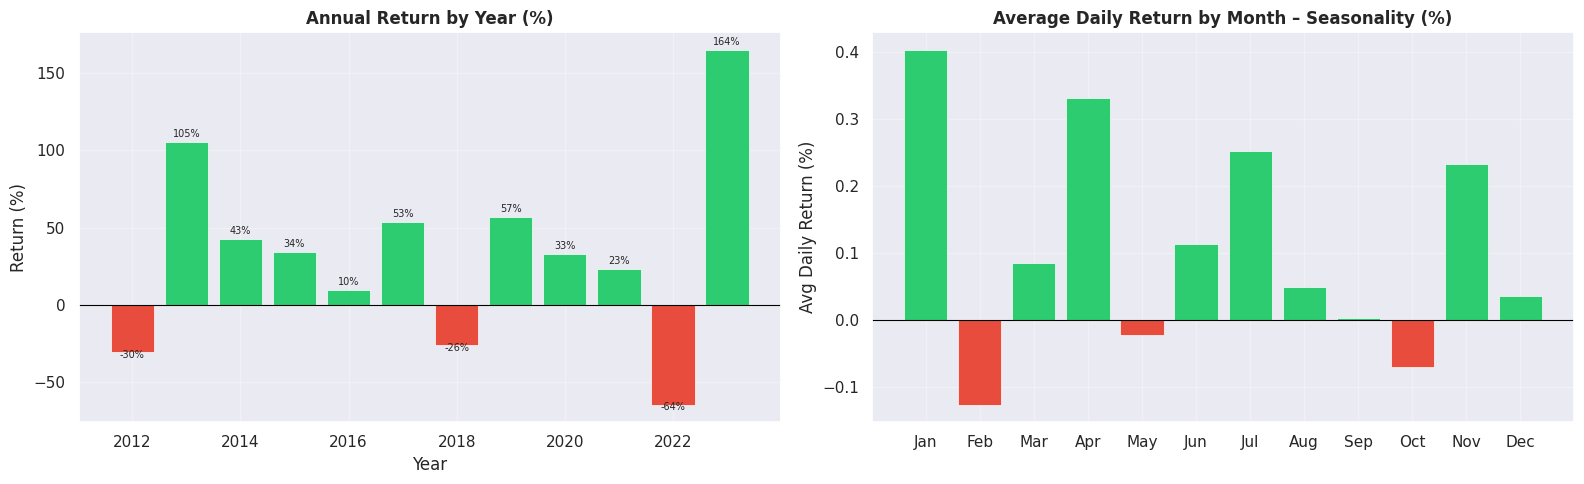


ANNUAL RETURNS:
  N 2012 : -30.4%
  P 2013 : 105.3%
  P 2014 : 42.8%
  P 2015 : 34.1%
  P 2016 : 9.9%
  P 2017 : 53.4%
  N 2018 : -25.7%
  P 2019 : 56.6%
  P 2020 : 33.1%
  P 2021 : 23.1%
  N 2022 : -64.2%
  P 2023 : 164.5%
Yearly & Monthly Returns


In [12]:
# annual return = compound all daily returns within the year
yearly = df.groupby("Year")["Daily_Return"].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()
yearly.columns = ["Year", "Annual_Return"]
yearly["Color"] = yearly["Annual_Return"].apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c")

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_avg = (df.groupby("Month_Name")["Daily_Return"]
                 .mean()
                 .reindex(month_order) * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# yearly bar chart
bars = axes[0].bar(yearly["Year"], yearly["Annual_Return"] * 100,
                   color=yearly["Color"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Annual Return by Year (%)", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Return (%)")
axes[0].axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, yearly["Annual_Return"] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (2 if val >= 0 else -5),
                 f"{val:.0f}%", ha="center", va="bottom", fontsize=7)

# monthly seasonality
month_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in monthly_avg]
axes[1].bar(monthly_avg.index, monthly_avg.values, color=month_colors,
            edgecolor="white", linewidth=0.5)
axes[1].set_title("Average Daily Return by Month – Seasonality (%)", fontweight="bold")
axes[1].set_ylabel("Avg Daily Return (%)")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(OUTPUT + "04_yearly_monthly_returns.png", dpi=150)
plt.show()
print("\nANNUAL RETURNS:")
for _, row in yearly.iterrows():
    sign = "P" if row["Annual_Return"] >= 0 else "N"
    #P-POSITIVE, N-NEGATIVE
    print(f"  {sign} {int(row['Year'])} : {row['Annual_Return']*100:.1f}%")
print("Yearly & Monthly Returns")

## Inferences

### Annual Return by Year

**Overall Trend is Bullish**
The majority of years show positive returns (green bars), indicating a generally strong upward trend in the asset over the decade.

**Notable Outlier Year: 2023**
The 164% return in 2023 is extraordinarily high and stands out as the best-performing year by a wide margin, suggesting either a massive recovery rally or a breakout event.

**Bear Years Were Few but Sharp**
Only 3 years recorded negative returns — 2013 (−30%), 2018 (−28%), and 2022 (−64%). The 2022 drawdown of −64% is the worst on record, suggesting high volatility and likely a severe market correction or crypto/growth asset crash.

**High Volatility Asset**
The wide range of returns, from −64% to +164% , points to an extremely volatile asset. This is not typical of blue-chip stocks; it resembles crypto, small-cap equities, or a leveraged ETF.

**Post-Crash Recoveries Are Strong**
After each negative year, the asset bounced back significantly (e.g., 2019 after 2018, 2023 after 2022), suggesting mean-reversion behavior or strong underlying demand.

---

### Average Daily Return by Month — Seasonality

**January is the Strongest Month**
With an average daily return of ~0.40%, January shows the highest positive seasonality, consistent with the well-known **"January Effect"** seen in many markets.

**February is the Weakest Month**
February is clearly the worst-performing month (~−0.10%), making it a historically unfavorable period to hold this asset.

**April and March Also Strong**
Spring months (March ~+0.33%, April ~+0.11%) show solid positive seasonality, suggesting Q1 (excluding Feb) is generally a good period.

**October and August Are Weak**
Both show negative or near-zero average daily returns, consistent with the **"October Effect"** narrative in financial markets.

**November is Surprisingly Strong**
A strong positive bar in November (~+0.23%) suggests end-of-year accumulation or seasonal buying pressure.

**December is Relatively Flat**
Despite holiday optimism, December barely contributes positively, contradicting the common "Santa Claus Rally" expectation for this particular asset.


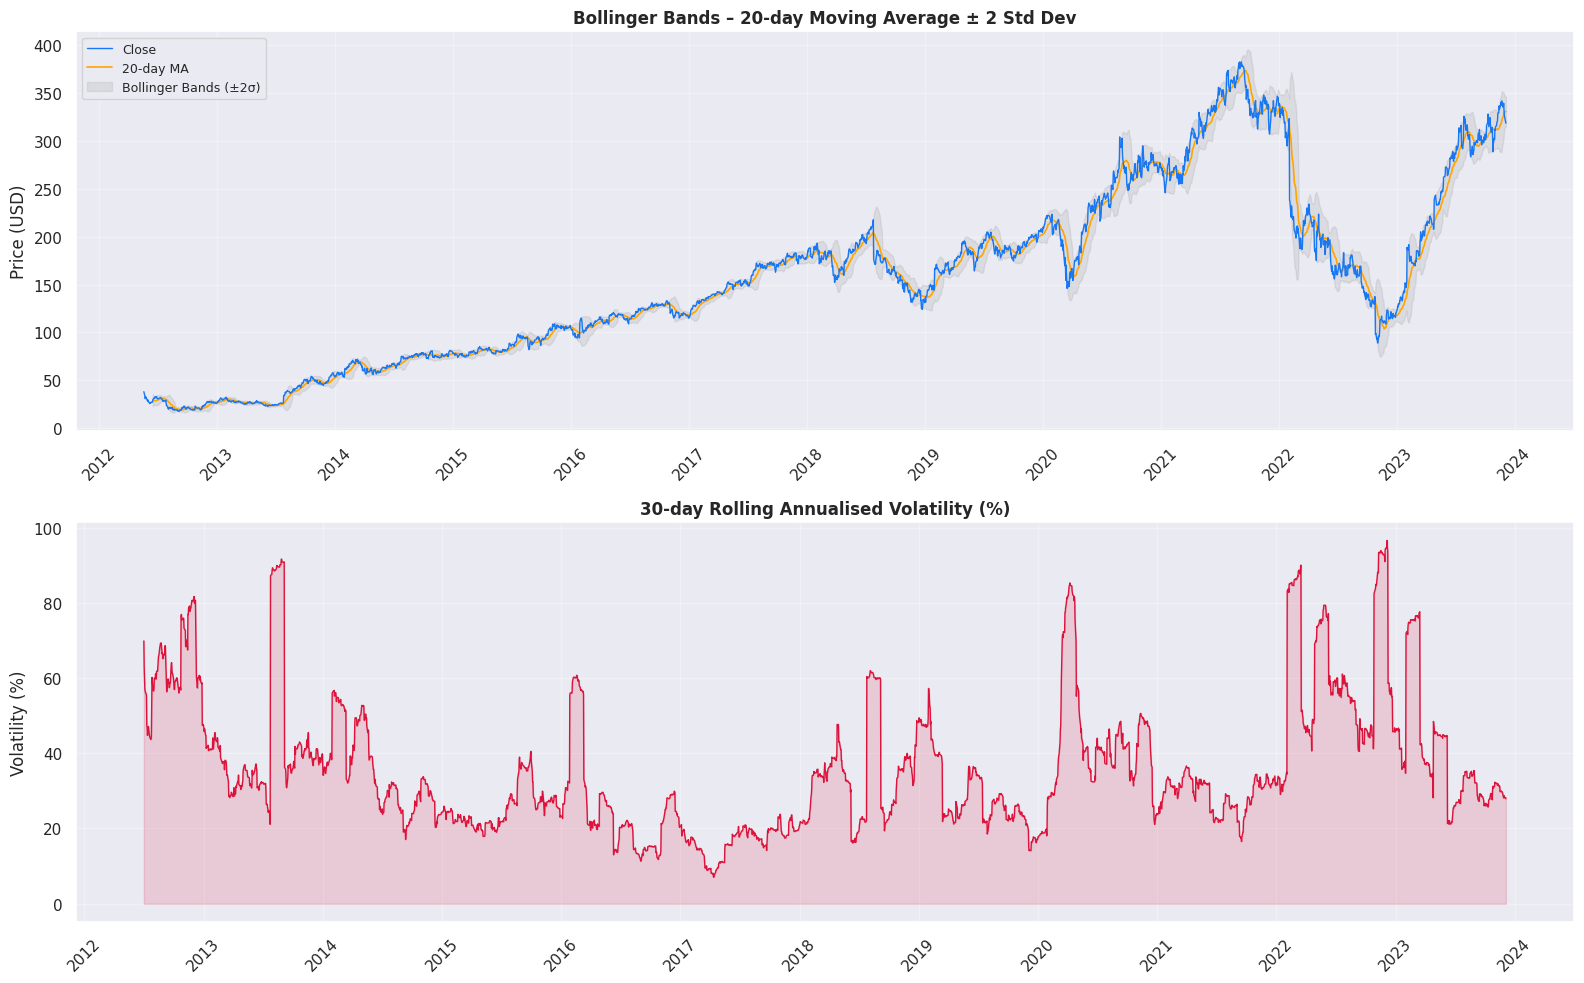

Volatility & Bollinger Bands


In [13]:
df["MA20"]       = df["Close"].rolling(20).mean()
df["STD20"]      = df["Close"].rolling(20).std()
df["Upper_Band"] = df["MA20"] + 2 * df["STD20"]
df["Lower_Band"] = df["MA20"] - 2 * df["STD20"]
df["Rolling_Vol_30"] = df["Daily_Return"].rolling(30).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Bollinger Bands
axes[0].plot(df["Date"], df["Close"], color="#1877F2", linewidth=1, label="Close", zorder=3)
axes[0].plot(df["Date"], df["MA20"],  color="orange",  linewidth=1.2, label="20-day MA")
axes[0].fill_between(df["Date"], df["Lower_Band"], df["Upper_Band"],
                     alpha=0.15, color="gray", label="Bollinger Bands (±2σ)")
axes[0].set_title("Bollinger Bands – 20-day Moving Average ± 2 Std Dev", fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# rolling volatility
axes[1].plot(df["Date"], df["Rolling_Vol_30"], color="crimson", linewidth=1)
axes[1].fill_between(df["Date"], df["Rolling_Vol_30"], alpha=0.15, color="crimson")
axes[1].set_title("30-day Rolling Annualised Volatility (%)", fontweight="bold")
axes[1].set_ylabel("Volatility (%)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())

for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT + "05_volatility_bollinger.png", dpi=150)
plt.show()
print("Volatility & Bollinger Bands")

(Price, Moving Average & Bollinger Bands)

1. The stock exhibits a strong long-term upward trend despite experiencing multiple market corrections.

2. The 20-day moving average helps identify short-term trend direction, where prices above it indicate bullish momentum.

3. Periods where the stock falls below the moving average reflect bearish sentiment and increased selling pressure.

4. Narrow Bollinger Bands indicate stable market conditions with lower volatility.

5. Wide Bollinger Bands during periods such as 2020 and 2022–2023 suggest high volatility, uncertainty, and large price fluctuations.

(30-Day Rolling Annualised Volatility)

1. The chart highlights how stock price volatility changes over time.

2. Major volatility spikes are observed during periods such as 2020 and 2022–2023, indicating unstable market conditions.

3. High volatility reflects strong investor reactions, panic selling, or aggressive buying activity.

4. Low volatility periods indicate relatively stable market behavior and reduced uncertainty.

5. The graph demonstrates volatility clustering, where high-volatility periods continue for some time before stabilizing.

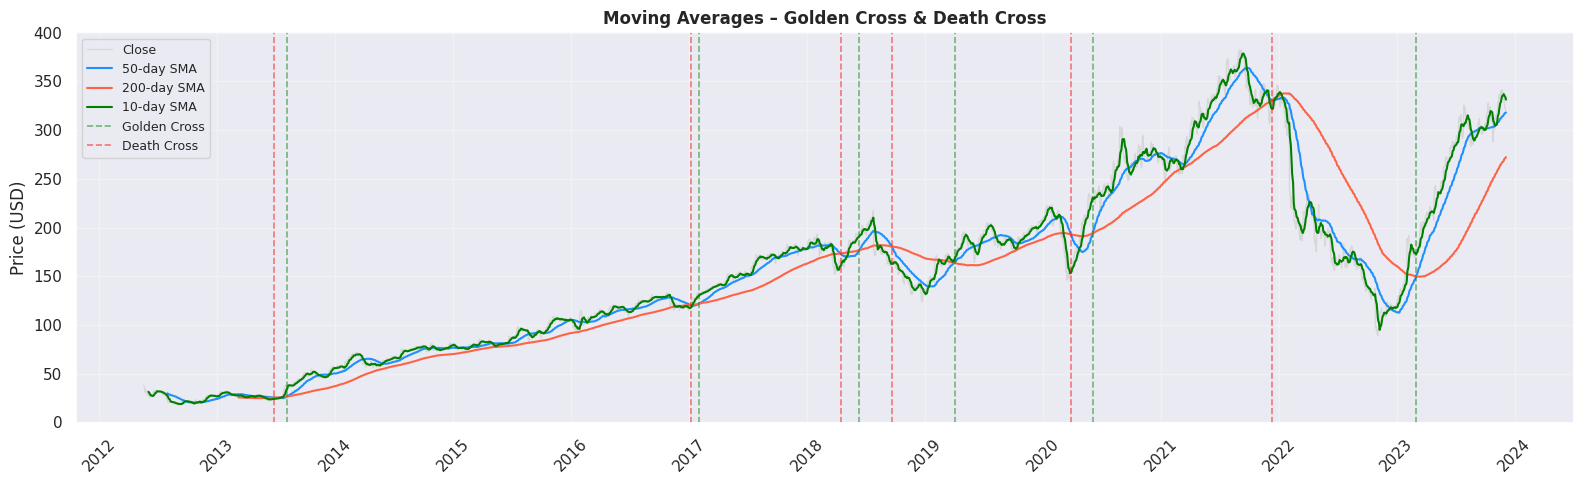


Golden Crosses detected : 6
Death Crosses detected  : 6
Moving Averages


In [14]:
df["MA50"]  = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()
df["MA10"] = df["Close"].rolling(10).mean()

cross   = df["MA50"] - df["MA200"]
golden  = df[(cross > 0) & (cross.shift(1) <= 0)]
death   = df[(cross < 0) & (cross.shift(1) >= 0)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["Date"], df["Close"], color="lightgray", linewidth=1,   label="Close",    alpha=0.8)
ax.plot(df["Date"], df["MA50"],  color="dodgerblue", linewidth=1.5, label="50-day SMA")
ax.plot(df["Date"], df["MA200"], color="tomato",     linewidth=1.5, label="200-day SMA")
ax.plot(df["Date"], df["MA10"], color="green",     linewidth=1.5, label="10-day SMA")

for i, (_, row) in enumerate(golden.iterrows()):
    ax.axvline(row["Date"], color="green", alpha=0.5, linewidth=1.2, linestyle="--",
               label="Golden Cross" if i == 0 else "")
for i, (_, row) in enumerate(death.iterrows()):
    ax.axvline(row["Date"], color="red", alpha=0.5, linewidth=1.2, linestyle="--",
               label="Death Cross" if i == 0 else "")

ax.set_title("Moving Averages – Golden Cross & Death Cross", fontweight="bold")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT + "06_moving_averages.png", dpi=150)
plt.show()

print(f"\nGolden Crosses detected : {len(golden)}")
print(f"Death Crosses detected  : {len(death)}")
print("Moving Averages")

a) Moving Averages

We have used 10-days(FMA), 50-days(FMA) and 200-days(SMA) moving averages in our analysis.

1. The chart indicates a strong bullish trend from 2012 to 2018, where the stock price steadily increased and the short-term moving averages remained mostly above the long-term moving average.

 2. The 10-day and 50-day moving averages closely tracked price momentum, while the 200-day moving average confirmed the long-term upward trend. Later, a sharp decline caused bearish crossover signals, followed by a gradual recovery phase.

3. From 2018 to 2022, the 10-day MA reacts very fast to price movements.
Sharp rises and falls are reflected immediately. It captures short-term market sentiment.

4. Instead of reacting instantly:

 Wait a few candles/days

 See if the crossover sustains

If it quickly reverses → false signal

If it continues downward → real trend change

5. The 2022 represents a Bearish crossover (also known as “Death Cross” in longer-term cases). Here sellers becomes stronger than buyers. The price starts decreasing and sellers dominate the market.

6. After 2023, the FMA moved below the SMA until 2024. Later, the stock price began to rise again, indicating increased buying interest. This could be considered a good opportunity to buy the stock at a relatively lower price(Bullish crossover or Golden cross).


TOP 10 BEST DAYS:
      Date      Close  Daily_Return
2013-07-25  34.360001         29.61
2023-02-02 188.770004         23.28
2012-10-24  23.230000         19.13
2022-04-28 205.729996         17.59
2016-01-28 109.110001         15.52
2014-01-30  61.080002         14.10
2023-04-27 238.559998         13.93
2012-11-14  22.360001         12.59
2019-01-31 166.690002         10.82
2022-11-10 111.870003         10.25

TOP 10 WORST DAYS:
      Date      Close  Daily_Return
2022-02-03 237.759995        -26.39
2022-10-27  97.940002        -24.56
2018-07-26 176.259995        -18.96
2020-03-16 146.009995        -14.25
2012-07-27  23.709999        -11.69
2012-05-21  34.029999        -10.99
2012-05-29  28.840000         -9.62
2022-09-13 153.130005         -9.37
2020-03-12 154.470001         -9.26
2012-09-24  20.790001         -9.06


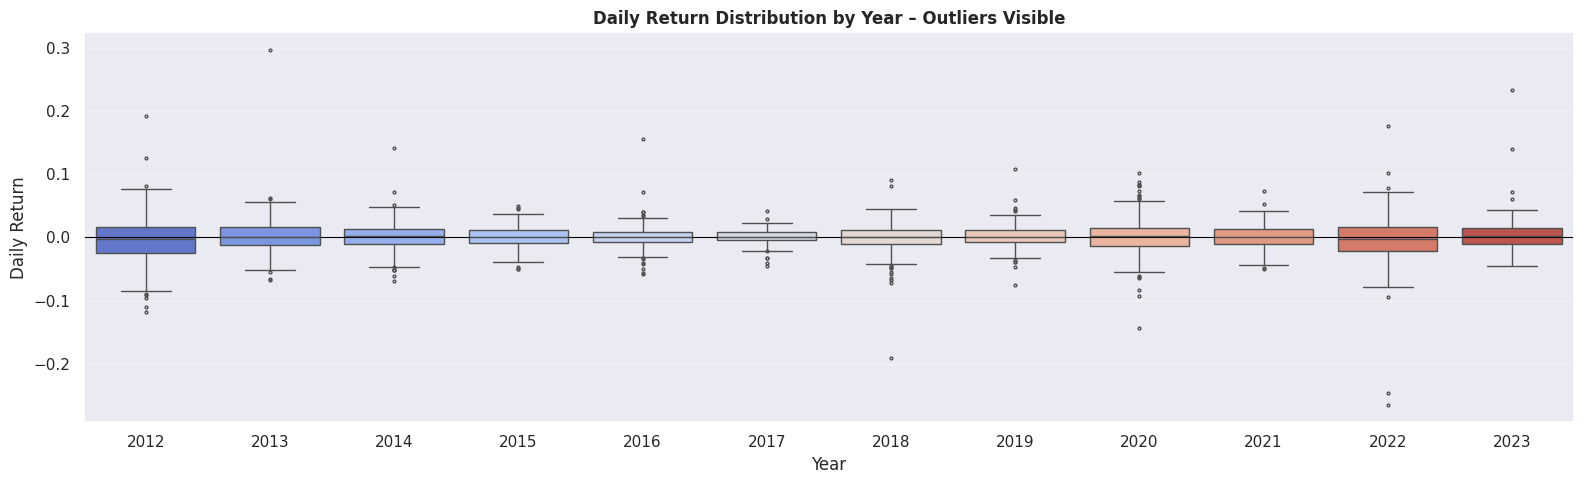

Box Plot by Year


In [15]:

cols = ["Date", "Close", "Daily_Return"]
top10_best  = df.nlargest(10,  "Daily_Return")[cols].copy()
top10_worst = df.nsmallest(10, "Daily_Return")[cols].copy()
top10_best["Daily_Return"]  = (top10_best["Daily_Return"]  * 100).round(2)
top10_worst["Daily_Return"] = (top10_worst["Daily_Return"] * 100).round(2)

print("\nTOP 10 BEST DAYS:")
print(top10_best.to_string(index=False))
print("\nTOP 10 WORST DAYS:")
print(top10_worst.to_string(index=False))

# box plot of returns by year
fig, ax = plt.subplots(figsize=(16, 5))
df_clean = df.dropna(subset=["Daily_Return"])
sns.boxplot(data=df_clean, x="Year", y="Daily_Return",
            palette="coolwarm", fliersize=2, ax=ax)
ax.set_title("Daily Return Distribution by Year – Outliers Visible", fontweight="bold")
ax.set_ylabel("Daily Return")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUTPUT + "09_boxplot_by_year.png", dpi=150)
plt.show()
print("Box Plot by Year")

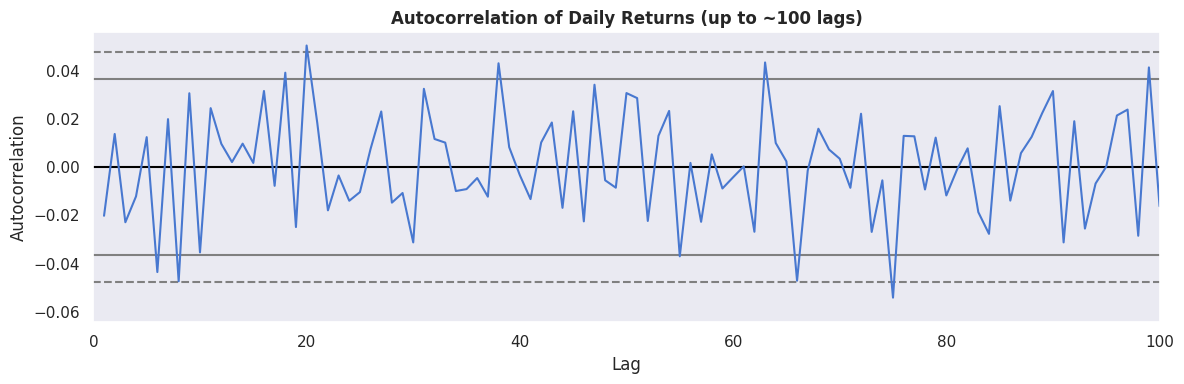

In [16]:
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(returns, ax=ax)
ax.set_title("Autocorrelation of Daily Returns (up to ~100 lags)", fontweight="bold")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT + "11_autocorrelation.png", dpi=150)
plt.show()

Final Summary


In [17]:

start_price = df["Close"].iloc[0]
end_price   = df["Close"].iloc[-1]
overall_ret = (end_price / start_price - 1) * 100
ann_vol     = returns.std() * np.sqrt(252) * 100
best_day    = df.loc[df["Daily_Return"].idxmax()]
worst_day   = df.loc[df["Daily_Return"].idxmin()]

print("\n" + "=" * 58)
print("         META STOCK EDA – FINAL SUMMARY")
print("=" * 58)
print(f"  Period              : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Total Trading Days  : {len(df)}")
print(f"  Start Price         : ${start_price:.2f}")
print(f"  End Price           : ${end_price:.2f}")
print(f"  Overall Return      : {overall_ret:.1f}%")
print(f"  Ann. Volatility     : {ann_vol:.2f}%")
print(f"  Best Single Day     : +{best_day['Daily_Return']*100:.2f}%  ({best_day['Date'].date()})")
print(f"  Worst Single Day    : {worst_day['Daily_Return']*100:.2f}%  ({worst_day['Date'].date()})")
print(f"  Avg Daily Return    : {returns.mean()*100:.4f}%")
print(f"  Return Skewness     : {returns.skew():.4f}")
print(f"  Return Kurtosis     : {returns.kurtosis():.4f}")
print("=" * 58)


         META STOCK EDA – FINAL SUMMARY
  Period              : 2012-05-18 → 2023-12-05
  Total Trading Days  : 2906
  Start Price         : $38.23
  End Price           : $318.29
  Overall Return      : 732.6%
  Ann. Volatility     : 40.21%
  Best Single Day     : +29.61%  (2013-07-25)
  Worst Single Day    : -26.39%  (2022-02-03)
  Avg Daily Return    : 0.1051%
  Return Skewness     : 0.2921
  Return Kurtosis     : 20.8541
